# Deep Neural Network Architecture

1. Single Neuron
2. Single-layer Network
3. Hidden Layers
5. Fully connected Dense layers
6. Neurons/layer
7. Depth vs Width
8. Regularization

$ Z = W.X + b $

then

$ a = F(z) $

$$ MNIST CLASSIFICATION $$

In [ ]:
# import torch
# print(torch.__version__)

2.14.0


In [ ]:
import torch
print("CUDA Available:", torch.cuda.is_available())
print("CUDA Version:", torch.version.cuda)

CUDA Available: False
CUDA Version: None


In [ ]:
# import tensorflow as tf


In [69]:
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt



In [70]:
# load the data

(X_train,y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print(X_train.shape,X_test.shape, y_train.shape, y_test.shape)

(60000, 28, 28) (10000, 28, 28) (60000,) (10000,)


In [38]:
# inspect
X_train[10]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  42, 118,
        219, 166, 118, 118,   6,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 103, 242, 254,
        254, 254, 254, 254,  66,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

In [39]:
print(X_train[10])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  42 118 219 166 118 118   6
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 103 242 254 254 254 254 254  66
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  18 232 254 254 254 254 254 238
   70   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 104 244 254 224 254 254 254
  141   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 207 254 210 25

In [40]:
# Data Preprocessing - Flatten

X_train = X_train.reshape(-1,28*28)
X_test = X_test.reshape(-1,28*28)

# Normalization

X_train.shape

(60000, 784)

In [41]:
X_train[10]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,  42, 118, 219, 166, 118, 118,   6,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0, 103, 242, 254, 254, 254, 254,
       254,  66,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,  18, 232, 25

In [42]:
# normalize
X_train = X_train/255.0
X_test = X_test/255.0

X_train[10]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

## 1. One Neuron Architecture

In [43]:
model_single = keras.models.Sequential()
model_single.add(keras.layers.Dense(1, input_shape=(28*28,)))
model_single.add(keras.layers.Dense(10, activation='softmax'))
model_single.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                │ (None, 1)              │           785 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │            20 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 805 (3.14 KB)

 Trainable params: 805 (3.14 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
# see the weigth matrix
for layer in model_single.layers:
    print(layer.name)
    weights,bias = layer.get_weights()
    print(bias.shape)
    print(weights.shape)
    print(weights[:3])

dense_19
(1,)
(784, 1)
[[-0.00192083]
 [-0.06618926]
 [ 0.01867011]]
dense_20
(10,)
(1, 10)
[[ 0.07885295 -0.49721923 -0.47099385 -0.3673872   0.6142035  -0.01273316
  -0.57940036  0.46384507  0.2884193   0.19785881]]


In [45]:
# compilation
model_single.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.1),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [46]:
# train the model with data
model_single.fit(X_train,y_train,epochs=10, batch_size = 128)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 292us/step - accuracy: 0.2747 - loss: 1.7395
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 283us/step - accuracy: 0.3417 - loss: 1.6216
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 302us/step - accuracy: 0.3618 - loss: 1.5949
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 278us/step - accuracy: 0.3740 - loss: 1.5825
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 276us/step - accuracy: 0.3830 - loss: 1.5727
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 268us/step - accuracy: 0.3925 - loss: 1.5649
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 278us/step - accuracy: 0.4065 - loss: 1.5582
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 287us/step - accuracy: 0.4117 - loss: 1.5541
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 277us/step - accuracy: 0.4142 - loss: 1.5512
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 278us/step - accuracy: 0.4176 - loss: 1.5472


`Observation -
**1 layer for Hudden and 10 neuron @ O/p - > Low convergence, showing poor Loss metrics**`

## Shallow Network

In [47]:
model_shallow = keras.models.Sequential()
model_shallow.add(keras.layers.Dense(100, input_shape=(28*28,),activation='relu'))
model_shallow.add(keras.layers.Dense(10, activation='softmax'))
model_shallow.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
# model compile
model_shallow.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.1),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [49]:
# train
model_shallow.fit(X_train,y_train,epochs=10, batch_size = 128, validation_split=0.2)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 706us/step - accuracy: 0.8634 - loss: 0.5069 - val_accuracy: 0.9122 - val_loss: 0.3079
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 571us/step - accuracy: 0.9200 - loss: 0.2819 - val_accuracy: 0.9330 - val_loss: 0.2393
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 643us/step - accuracy: 0.9341 - loss: 0.2327 - val_accuracy: 0.9392 - val_loss: 0.2112
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 531us/step - accuracy: 0.9430 - loss: 0.1999 - val_accuracy: 0.9452 - val_loss: 0.1952
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 531us/step - accuracy: 0.9498 - loss: 0.1766 - val_accuracy: 0.9535 - val_loss: 0.1699
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 545us/step - accuracy: 0.9546 - loss: 0.1578 - val_accuracy: 0.9549 - val_loss: 0.1586
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 541us/step - accuracy: 0.9597 - loss: 0.1435 - val_accuracy: 0.9585 - val_loss: 0.1470
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 545us/step - accuracy: 0.9628 - loss: 0.1313 - 

In [50]:
# testing
model_shallow.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 263us/step - accuracy: 0.9634 - loss: 0.1224


[0.1224042996764183, 0.9634000062942505]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 257us/step - accuracy: 0.9634 - loss: 0.1224


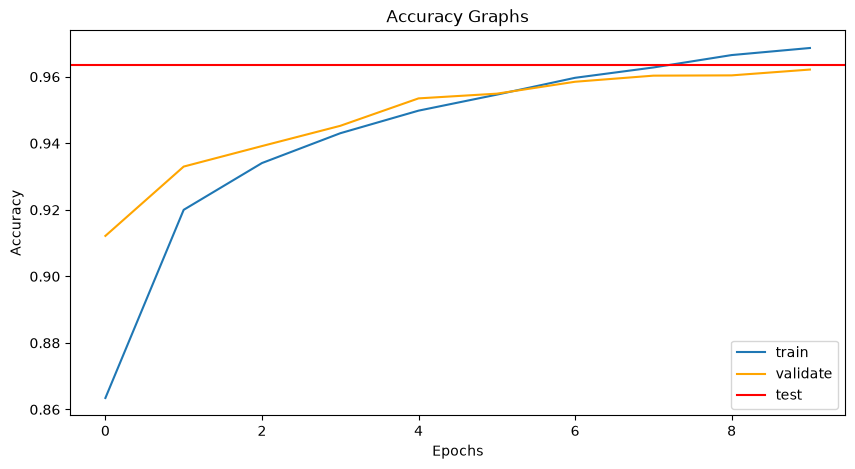

In [51]:
# draw graph for accuracy of train,test,validate
plt.figure(figsize=(10,5))
plt.plot(model_shallow.history.history['accuracy'],label = 'train')
plt.plot(model_shallow.history.history['val_accuracy'], color='orange', label = 'validate')
plt.title('Accuracy Graphs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['train','test'])
plt.axhline(model_shallow.evaluate(X_test,y_test)[1], label = 'test', color='red')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 273us/step - accuracy: 0.9634 - loss: 0.1224


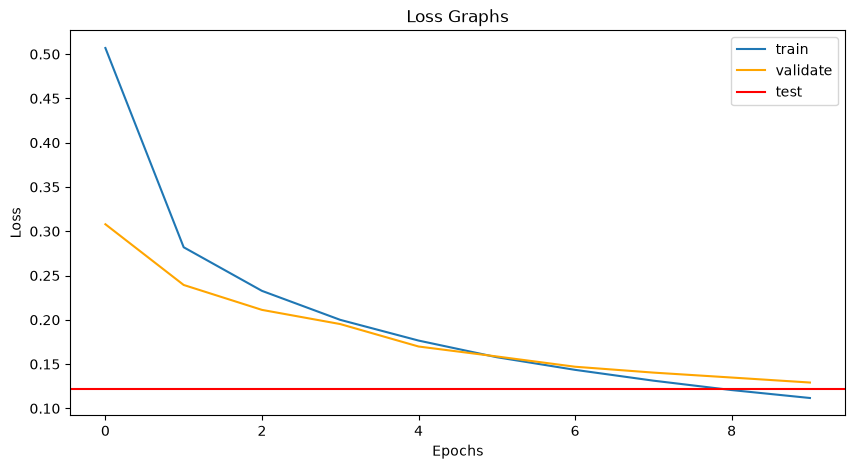

In [52]:
# loss graph
plt.figure(figsize=(10,5))
plt.plot(model_shallow.history.history['loss'],label = 'train')
plt.plot(model_shallow.history.history['val_loss'], color='orange', label = 'validate')
plt.title('Loss Graphs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['train','test'])
plt.axhline(model_shallow.evaluate(X_test,y_test)[0], label = 'test', color='red')
plt.legend()
plt.show()

In [53]:
# check model weights
for layer in model_shallow.layers:
    print(layer.name)
    weights,bias = layer.get_weights()
    print(bias.shape)
    print(weights.shape)
    print(weights[:1])
    print(bias[:5])

dense_21
(100,)
(784, 100)
[[ 0.01549992  0.01146227  0.07529339 -0.03504618  0.04776973 -0.07101467
  -0.04647093 -0.05471603  0.06446835 -0.0167131  -0.03124489  0.02530028
  -0.04259066  0.028416   -0.05078773 -0.00277499 -0.03545973 -0.05544593
  -0.03157083 -0.02732775 -0.03841892 -0.04473808  0.07879706 -0.08196169
  -0.03276405 -0.04360184 -0.06256567 -0.0626324  -0.04546851  0.07990439
   0.06581266 -0.02786608 -0.07838442  0.03614189 -0.0549579   0.04585174
  -0.02838259 -0.05120022 -0.02639555  0.05691266 -0.02738868 -0.04787659
   0.02980604 -0.05772032  0.02596898  0.03873578  0.06121604  0.004285
   0.08049071  0.06758617 -0.01218155 -0.03104493  0.06389593  0.05378895
  -0.02546145 -0.05904849 -0.00399759 -0.06017691  0.02904477  0.05425051
  -0.04401156 -0.0802378   0.06666604 -0.00551513 -0.00458419  0.06924339
  -0.02380532  0.08058743 -0.08173595  0.08167177 -0.07076015 -0.01432223
  -0.02613987  0.01296178  0.0211118  -0.03780889  0.052791   -0.0664428
   0.06060751 

## 3. Fully Connected Layers

In [54]:
model_dnn = keras.models.Sequential()

#hidden layers
model_dnn.add(keras.layers.Dense(20, input_shape=(28*28,),activation='relu'))
model_dnn.add(keras.layers.Dense(20, activation='relu'))
model_dnn.add(keras.layers.Dense(20, activation='relu'))
model_dnn.add(keras.layers.Dense(20, activation='relu'))
model_dnn.add(keras.layers.Dense(20, activation='relu'))

#output layer
model_dnn.add(keras.layers.Dense(10, activation='softmax'))
model_dnn.summary()


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                │ (None, 20)             │        15,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 10)             │           210 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,590 (68.71 KB)

 Trainable params: 17,590 (68.71 KB)

 Non-trainable params: 0 (0.00 B)

**Observation - By increasing depth the parameter size actually decreases, given number of neurons remain same**

In [55]:
# compile the dnn
model_dnn.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.1),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [56]:
# fit
model_dnn.fit(X_train,y_train,epochs=10, batch_size = 128, validation_split=0.2)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 619us/step - accuracy: 0.5725 - loss: 1.2330 - val_accuracy: 0.8903 - val_loss: 0.3866
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 477us/step - accuracy: 0.8905 - loss: 0.3770 - val_accuracy: 0.9221 - val_loss: 0.2800
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 434us/step - accuracy: 0.9217 - loss: 0.2742 - val_accuracy: 0.9313 - val_loss: 0.2378
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 437us/step - accuracy: 0.9348 - loss: 0.2251 - val_accuracy: 0.9417 - val_loss: 0.1992
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 475us/step - accuracy: 0.9426 - loss: 0.1951 - val_accuracy: 0.9421 - val_loss: 0.1966
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 462us/step - accuracy: 0.9473 - loss: 0.1757 - val_accuracy: 0.9522 - val_loss: 0.1672
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 465us/step - accuracy: 0.9520 - loss: 0.1603 - val_accuracy: 0.9448 - val_loss: 0.1912
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 480us/step - accuracy: 0.9563 - loss: 0.1485 - 

In [57]:
# test
model_dnn.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 261us/step - accuracy: 0.9479 - loss: 0.1787


[0.1786913126707077, 0.9478999972343445]

## Perfect Architectures for DNN

In [58]:
# achitecture of 784-> 2048->2048 - > 10
model_dnn_perfect = keras.models.Sequential()

#hidden layers
model_dnn_perfect.add(keras.layers.Dense(2048, input_shape=(28*28,),activation='relu'))
model_dnn_perfect.add(keras.layers.Dense(2048, activation='relu'))
model_dnn_perfect.add(keras.layers.Dense(10, activation='softmax'))
model_dnn_perfect.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_29 (Dense)                │ (None, 2048)           │     1,607,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 2048)           │     4,196,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,824,522 (22.22 MB)

 Trainable params: 5,824,522 (22.22 MB)

 Non-trainable params: 0 (0.00 B)

In [59]:
# compile
model_dnn_perfect.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.1),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [60]:
# train
model_dnn_perfect.fit(X_train,y_train,epochs=10, batch_size = 128, validation_split=0.2)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8842 - loss: 0.4243 - val_accuracy: 0.9325 - val_loss: 0.2347
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9426 - loss: 0.2016 - val_accuracy: 0.9542 - val_loss: 0.1645
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9586 - loss: 0.1466 - val_accuracy: 0.9622 - val_loss: 0.1334
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9671 - loss: 0.1148 - val_accuracy: 0.9668 - val_loss: 0.1171
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9743 - loss: 0.0928 - val_accuracy: 0.9703 - val_loss: 0.1071
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9787 - loss: 0.0767 - val_accuracy: 0.9718 - val_loss: 0.0971
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9822 - loss: 0.0644 - val_accuracy: 0.9733 - val_loss: 0.0898
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9860 - loss: 0.0543 - val_accu

In [61]:
# test
model_dnn_perfect.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9780 - loss: 0.0705


[0.07046663016080856, 0.9779999852180481]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9780 - loss: 0.0705


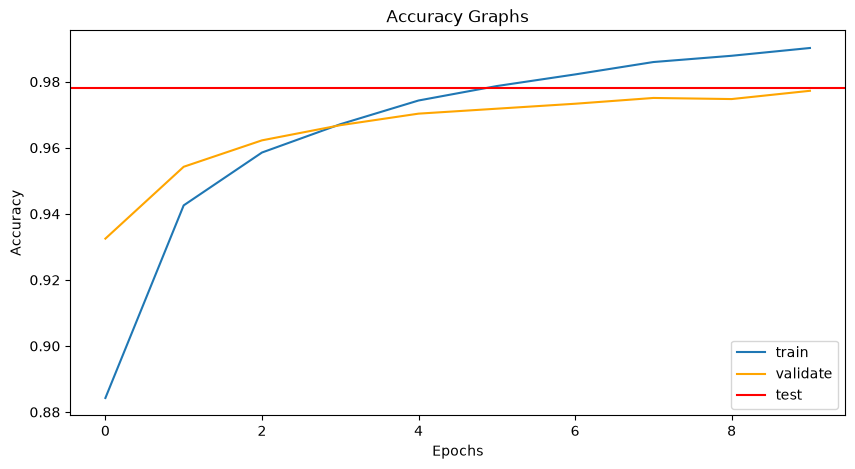

In [62]:
# plot
plt.figure(figsize=(10,5))
plt.plot(model_dnn_perfect.history.history['accuracy'],label = 'train')
plt.plot(model_dnn_perfect.history.history['val_accuracy'], color='orange', label = 'validate')
plt.title('Accuracy Graphs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['train','validate','test'])
plt.axhline(model_dnn_perfect.evaluate(X_test,y_test)[1], label = 'test', color='red')
plt.legend()
plt.show()

## Overfitting - Regularization

In [63]:
model_3 = keras.models.Sequential()

#hidden layers
model_3.add(keras.layers.Dense(20, input_shape=(28*28,),activation='relu'))
model_3.add(keras.layers.Dense(20, activation='relu'))
model_3.add(keras.layers.Dense(20, activation='relu'))
model_3.add(keras.layers.Dense(20, activation='relu'))
model_3.add(keras.layers.Dense(20, activation='relu'))


#output layer
model_3.add(keras.layers.Dense(10, activation='softmax'))
model_3.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 20)             │        15,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 10)             │           210 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,590 (68.71 KB)

 Trainable params: 17,590 (68.71 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
# compile
model_3.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.1),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [65]:
# epochs of 100
model_3.fit(X_train,y_train,epochs=100, batch_size = 128, validation_split=0.2)

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 781us/step - accuracy: 0.6691 - loss: 0.9769 - val_accuracy: 0.8843 - val_loss: 0.3896
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 511us/step - accuracy: 0.8999 - loss: 0.3423 - val_accuracy: 0.9215 - val_loss: 0.2659
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 522us/step - accuracy: 0.9228 - loss: 0.2588 - val_accuracy: 0.9363 - val_loss: 0.2150
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 515us/step - accuracy: 0.9365 - loss: 0.2146 - val_accuracy: 0.9410 - val_loss: 0.1995
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 491us/step - accuracy: 0.9437 - loss: 0.1902 - val_accuracy: 0.9420 - val_loss: 0.1972
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 463us/step - accuracy: 0.9490 - loss: 0.1705 - val_accuracy: 0.9519 - val_loss: 0.1702
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 441us/step - accuracy: 0.9522 - loss: 0.1611 - val_accuracy: 0.9481 - val_loss: 0.1738
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 440us/step - accuracy: 0.9551 - loss: 0

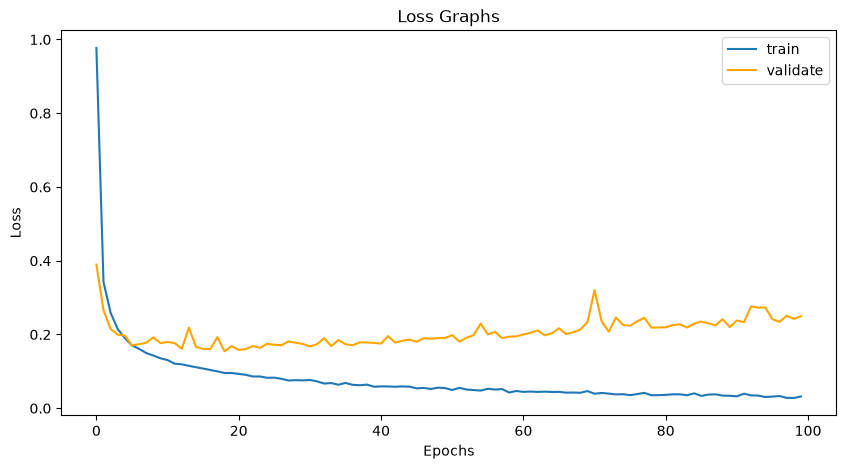

In [66]:
# plot train vs validate loss
plt.figure(figsize=(10,5))
plt.plot(model_3.history.history['loss'],label = 'train')
plt.plot(model_3.history.history['val_loss'], color='orange', label = 'validate')
plt.title('Loss Graphs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['train','validate'])

In [67]:
# 1. Early stopping
# 2. Dropouts
# 3. L2 Regularization

